## Práctica 2: Regresión lineal con BGD
Programa 1

#### Escuela Superior de Cómputo
Ingeniería en IA
<br>
Aprendizaje Automático<br>
**Robles Guzmán Naomi Isabel** <br><br>

<p>Consuelo Varinia García Mendoza</p>
<br>


---
## Especificaciones

### I. Para este programa se utilizará el dataset datos.csv
* Entrada: archivo *datos.csv*, número de iteraciones para SGD y $\alpha$

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import operator

In [34]:
# Leer datos
df = pd.read_csv('datos.csv')

X = df['x'].values.reshape(-1, 1) 
y = df['y'].values

# Parámetros de entrada
num_iteraciones_SGD = 10_000
alpha =  10e-8

### II. Divide *datos.csv* en 70% para entrenamiento y 30% para pruebas
Con los parámetros *shuffle=True* y *random_state=0*

In [35]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 0, shuffle=True)

### III. Con las bibliotecas de scikit-learn realiza las siguientes regresiones
* Regresión lineal con OLS
* Regresión Polinomial de grado 2 con OLS
* Regresión Polinomial de grado 3 con OLS
* Regresión lineal con SGD
* Regresión polinomial de grado 2 con SGD
* Regresión polinomial de grado 3 con SGD


In [36]:
# 1. Regresión lineal con OLS
modelo_lineal_ols = LinearRegression()
modelo_lineal_ols.fit(X_train.reshape(-1, 1), y_train)
y_pred_lineal_ols = modelo_lineal_ols.predict(X_test.reshape(-1, 1))

# 2. Regresión Polinomial de grado 2 con OLS
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train.reshape(-1, 1))
X_test_poly2 = poly2.transform(X_test.reshape(-1, 1))

modelo_poly2_ols = LinearRegression()
modelo_poly2_ols.fit(X_train_poly2, y_train)
y_pred_poly2_ols = modelo_poly2_ols.predict(X_test_poly2)

# 3. Regresión Polinomial de grado 3 con OLS
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train.reshape(-1, 1))
X_test_poly3 = poly3.transform(X_test.reshape(-1, 1))

modelo_poly3_ols = LinearRegression()
modelo_poly3_ols.fit(X_train_poly3, y_train)
y_pred_poly3_ols = modelo_poly3_ols.predict(X_test_poly3)

# 4. Regresión lineal con SGD
modelo_lineal_sgd = SGDRegressor(max_iter=num_iteraciones_SGD, learning_rate='constant', 
                                  eta0=alpha, random_state=0, tol=None)
modelo_lineal_sgd.fit(X_train.reshape(-1, 1), y_train)
y_pred_lineal_sgd = modelo_lineal_sgd.predict(X_test.reshape(-1, 1))

# 5. Regresión polinomial de grado 2 con SGD
modelo_poly2_sgd = SGDRegressor(max_iter=num_iteraciones_SGD, learning_rate='constant', 
                                 eta0=alpha, random_state=0, tol=None)
modelo_poly2_sgd.fit(X_train_poly2, y_train)
y_pred_poly2_sgd = modelo_poly2_sgd.predict(X_test_poly2)

# 6. Regresión polinomial de grado 3 con SGD
modelo_poly3_sgd = SGDRegressor(max_iter=num_iteraciones_SGD, learning_rate='constant', 
                                 eta0=alpha, random_state=0, tol=None)
modelo_poly3_sgd.fit(X_train_poly3, y_train)
y_pred_poly3_sgd = modelo_poly3_sgd.predict(X_test_poly3)

# Calcular métricas para cada modelo
modelos = {
    'Regresión lineal con OLS': (y_pred_lineal_ols, mean_squared_error(y_test, y_pred_lineal_ols), 
                                  r2_score(y_test, y_pred_lineal_ols)),
    'Regresión polinomial de grado 2 con OLS': (y_pred_poly2_ols, mean_squared_error(y_test, y_pred_poly2_ols), 
                                                 r2_score(y_test, y_pred_poly2_ols)),
    'Regresión polinomial de grado 3 con OLS': (y_pred_poly3_ols, mean_squared_error(y_test, y_pred_poly3_ols), 
                                                 r2_score(y_test, y_pred_poly3_ols)),
    'Regresión lineal con SGD': (y_pred_lineal_sgd, mean_squared_error(y_test, y_pred_lineal_sgd), 
                                 r2_score(y_test, y_pred_lineal_sgd)),
    'Regresión polinomial de grado 2 con SGD': (y_pred_poly2_sgd, mean_squared_error(y_test, y_pred_poly2_sgd), 
                                                 r2_score(y_test, y_pred_poly2_sgd)),
    'Regresión polinomial de grado 3 con SGD': (y_pred_poly3_sgd, mean_squared_error(y_test, y_pred_poly3_sgd), 
                                                 r2_score(y_test, y_pred_poly3_sgd))
}

# Lista de predicciones y títulos
predicciones = [
    (y_pred_lineal_ols, 'Regresión lineal con OLS', X_test, False),
    (y_pred_poly2_ols, 'Regresión polinomial grado 2 con OLS', X_test, True),
    (y_pred_poly3_ols, 'Regresión polinomial grado 3 con OLS', X_test, True),
    (y_pred_lineal_sgd, 'Regresión lineal con SGD', X_test, False),
    (y_pred_poly2_sgd, 'Regresión polinomial grado 2 con SGD', X_test, True),
    (y_pred_poly3_sgd, 'Regresión polinomial grado 3 con SGD', X_test, True)
]

# Resumen de resultados
print("\n" + "="*80)
print(f"{'Modelo':<45} {'MSE':>15} {'R²':>15}")
print("="*80)

for nombre, (_, mse, r2) in modelos.items():
    print(f"{nombre:<45} {mse:>15.6f} {r2:>15.6f}")

print("="*80)


Modelo                                                    MSE              R²
Regresión lineal con OLS                           296.094587        0.719805
Regresión polinomial de grado 2 con OLS            352.437384        0.666487
Regresión polinomial de grado 3 con OLS              8.487854        0.991968
Regresión lineal con SGD                           554.963137        0.474837
Regresión polinomial de grado 2 con SGD            872.467128        0.174382
Regresión polinomial de grado 3 con SGD             12.620635        0.988057


### III. Salida: gráfica para cada regresión
con distribución de los datos de prueba, [X_test,y_pred], en regresión polinomial ordenar los datos antes de pintar la curva predicha, resumen de resultados

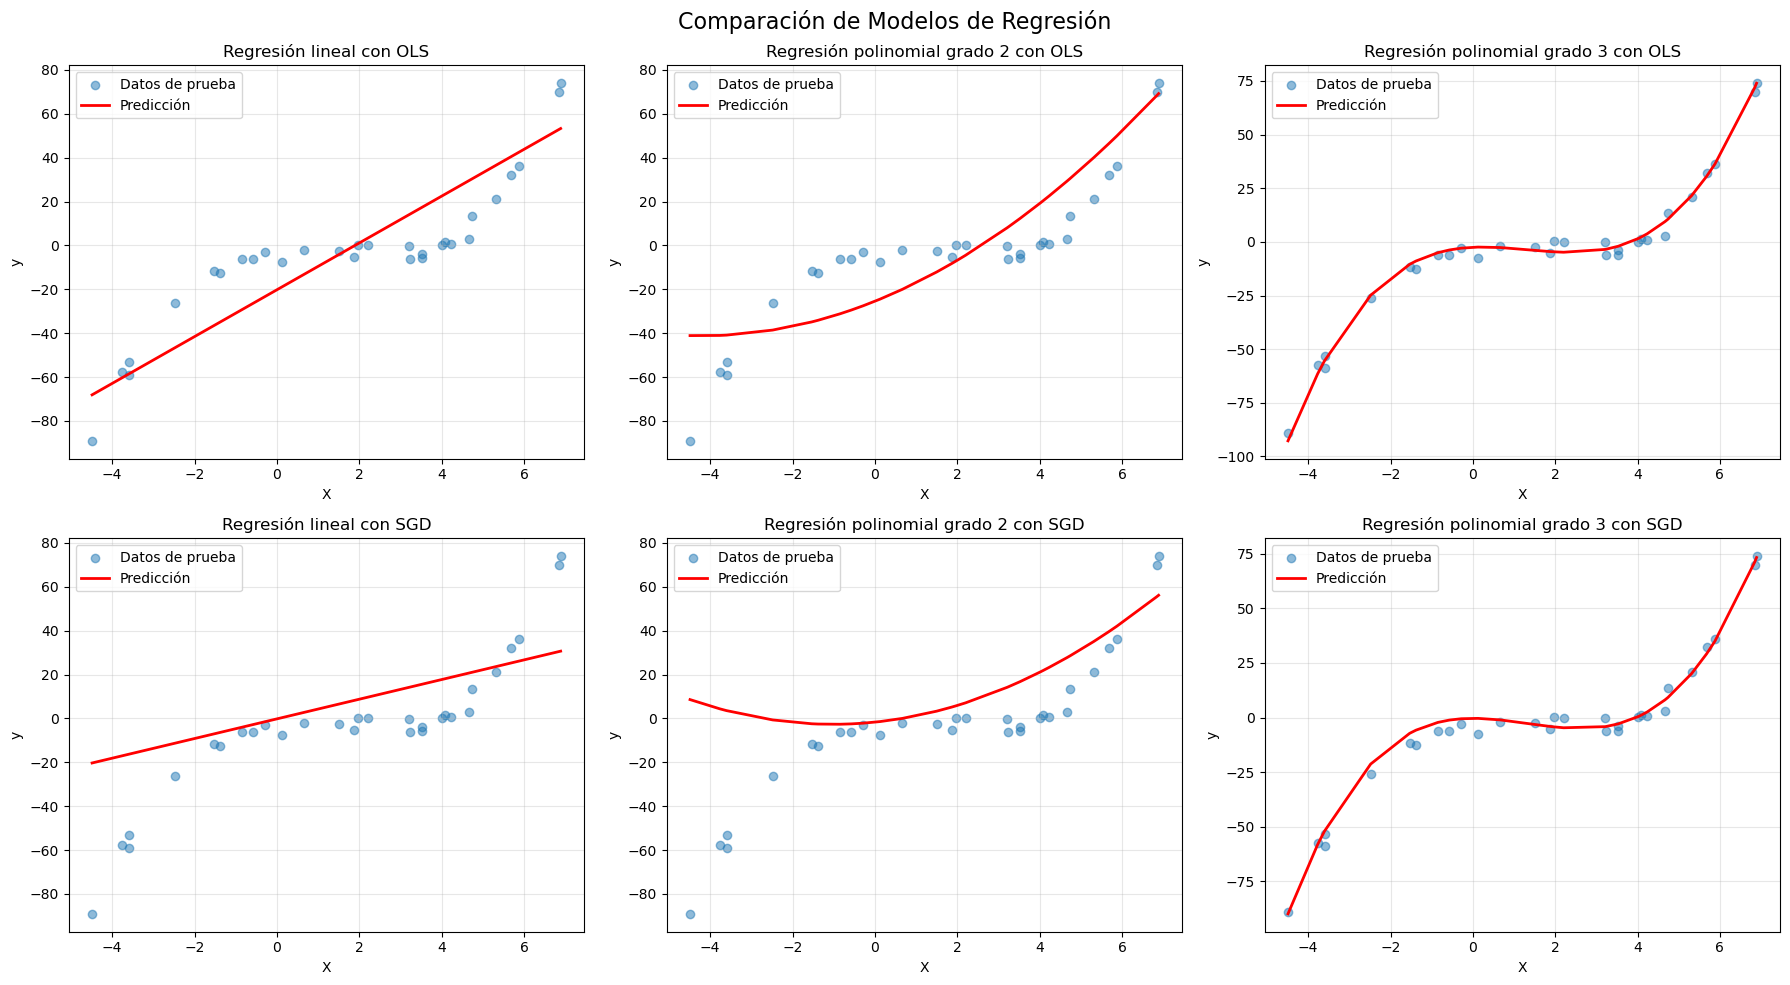

In [37]:

# Gráficas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación de Modelos de Regresión', fontsize=16)



for idx, (y_pred, titulo, X_vals, es_polinomial) in enumerate(predicciones):
    ax = axes[idx // 3, idx % 3]
    
    # Scatter de datos de prueba
    ax.scatter(X_test, y_test, alpha=0.5, label='Datos de prueba')
    
    # Ordenar datos para pintar la curva (tanto lineal como polinomial)
    indices_ordenados = np.argsort(X_vals, axis=0).ravel()
    ax.plot(X_vals[indices_ordenados], y_pred[indices_ordenados], 
            color='red', linewidth=2, label='Predicción')
    
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title(titulo)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()